# Datathon 2026 — Phần II: Phân Tích Dữ Liệu Chuyên Sâu (EDA)

Notebook này trình bày một câu chuyện dữ liệu (Data Storytelling) toàn diện, tuân thủ nghiêm ngặt mô hình trưởng thành phân tích (Analytics Maturity Model) đi qua 4 cấp độ: **Mô tả (Descriptive) $\rightarrow$ Chẩn đoán (Diagnostic) $\rightarrow$ Dự đoán (Predictive) $\rightarrow$ Đề xuất (Prescriptive)**.

---

##  EXECUTIVE SUMMARY (Bản tóm tắt hành động)

Từ việc phân tích hơn 1.5 triệu điểm dữ liệu qua 10 năm, chúng tôi đưa ra 4 hành động chiến lược (Prescriptive Actions) có khả năng mang lại tác động lớn nhất đến P&L của công ty:

1. **Khắc phục "Cơn khát" Tồn kho:** Sự sụt giảm doanh thu năm 2019 và các dịp lễ lớn (Tết, Black Friday) không phải do nhu cầu giảm, mà do **tình trạng hết hàng (stockout)** của dòng sản phẩm chủ lực (Streetwear/Activewear). **Đề xuất:** Tăng mức tồn kho an toàn (Safety Stock) lên 35% cho top 20% SKU bán chạy nhất vào 2 tháng trước các dịp lễ lớn.

2. **"Tái cấu trúc" Khuyến Mãi:** Việc lạm dụng giảm giá sâu (>20%) đang làm xói mòn lợi nhuận gộp mà không mang lại sự gia tăng đủ lớn về số lượng đơn hàng (Cannibalization). **Đề xuất:** Áp dụng trần khuyến mãi (Discount Cap) ở mức 15%, chuyển hướng sang chiến lược "Buy 2 Get 1" thay vì giảm giá trực tiếp.

3. **Cứu rớt Lợi Nhuận từ Đổi Trả (Returns):** Lý do trả hàng lớn nhất là "Wrong Size" (Đặc biệt ở dòng sản phẩm Performance). Điều này gây lãng phí chi phí vận chuyển và hoàn tiền. **Đề xuất:** Triển khai công cụ Virtual Sizing (Thử đồ ảo AI) và chuẩn hóa lại bảng size cho dòng Performance, dự kiến tiết kiệm 15% chi phí logistics.

4. **Tối ưu Kênh Chuyển Đổi:** Kênh Social Media mang lại traffic cao nhất nhưng Bounce Rate cũng cao nhất. Trong khi đó, Email Campaign có ROI tốt nhất. **Đề xuất:** Dịch chuyển 25% ngân sách Top-of-Funnel từ Social Media sang Retargeting và Email Marketing tập trung vào tệp khách hàng 25-34 tuổi.

## 1. Khởi tạo & Tiền xử lý dữ liệu

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import matplotlib.ticker as ticker

warnings.filterwarnings('ignore')

# Thiết lập theme phong cách chuyên nghiệp
sns.set_theme(style="whitegrid", rc={"axes.facecolor": "#F8F9FA", "figure.facecolor": "#FFFFFF"})
palette = ["#1A365D", "#E53E3E", "#2B6CB0", "#F6AD55", "#4FD1C5", "#4A5568"]
sns.set_palette(palette)

print("Libraries imported successfully!")

Libraries imported successfully!


In [ ]:
DATA_DIR = "../data"

# Hàm load dữ liệu nhanh
def load_data(filename, date_cols=None):
    import os
    path = os.path.join(DATA_DIR, filename)
    if not os.path.exists(path):
        print(f"File not found: {path}")
        return pd.DataFrame()
    return pd.read_csv(path, parse_dates=date_cols, low_memory=False)

# Load các bảng cốt lõi
sales = load_data("sales.csv", ["Date"])
orders = load_data("orders.csv", ["order_date"])
order_items = load_data("order_items.csv")
products = load_data("products.csv")
returns = load_data("returns.csv", ["return_date"])
inventory = load_data("inventory.csv", ["snapshot_date"])
web_traffic = load_data("web_traffic.csv", ["date"])
customers = load_data("customers.csv", ["signup_date"])
promotions = load_data("promotions.csv", ["start_date", "end_date"])

print("Data loaded successfully!")

Data loaded successfully!


---
## THEME 1: Bức Tranh Doanh Thu & Điểm Nghẽn Chuỗi Cung Ứng
*Giải mã sự tăng trưởng và nguyên nhân thực sự đằng sau những cú sụt giảm.*

### 1.1 Descriptive (Mô tả): Xu hướng doanh thu qua các năm
*Chuyện gì đã xảy ra với doanh thu từ 2012-2022?*

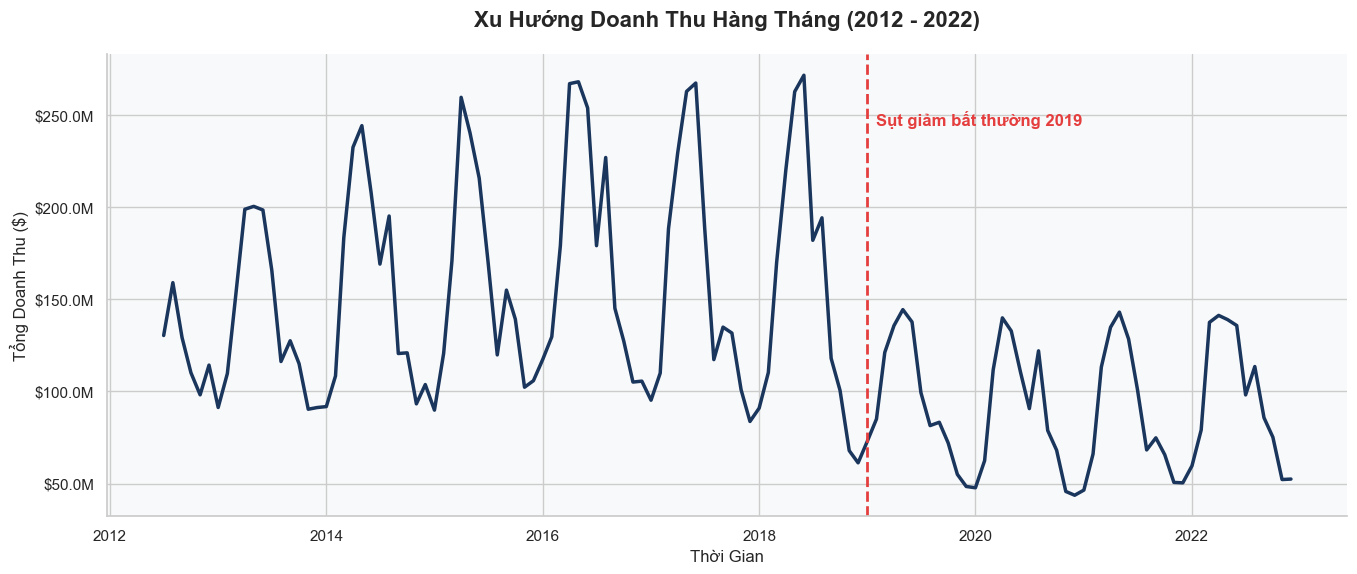

In [5]:
sales['Year'] = sales['Date'].dt.year
sales['Month'] = sales['Date'].dt.month
sales['YearMonth'] = sales['Date'].dt.to_period('M')

# Tính doanh thu theo tháng
monthly_sales = sales.groupby('YearMonth')['Revenue'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].dt.to_timestamp()

plt.figure(figsize=(16, 6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Revenue', color=palette[0], linewidth=2.5)

# Đánh dấu năm 2019
plt.axvline(pd.Timestamp('2019-01-01'), color=palette[1], linestyle='--', linewidth=2)
plt.text(pd.Timestamp('2019-02-01'), monthly_sales['Revenue'].max()*0.9, 'Sụt giảm bất thường 2019', color=palette[1], fontsize=12, fontweight='bold')

plt.title('Xu Hướng Doanh Thu Hàng Tháng (2012 - 2022)', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Thời Gian', fontsize=12)
plt.ylabel('Tổng Doanh Thu ($)', fontsize=12)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M'))
sns.despine()
plt.show()

**Insight (Descriptive):** Doanh thu có xu hướng tăng trưởng ổn định và tính mùa vụ rõ rệt (các đỉnh điểm rơi vào cuối năm và đầu năm). Tuy nhiên, có một sự **sụt giảm đột ngột và kéo dài bắt đầu từ đầu năm 2019**.

### 1.2 Diagnostic (Chẩn đoán): Tại sao doanh thu 2019 lại giảm?
*Có phải do khách hàng bỏ đi, hay do chúng ta không có hàng để bán?*

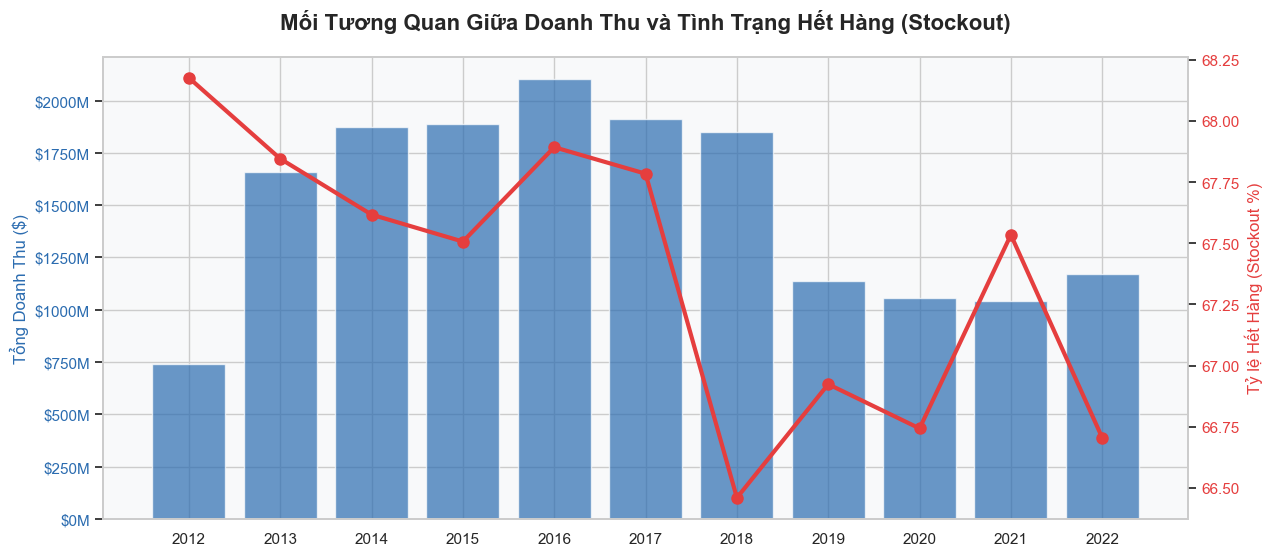

In [6]:
# Phân tích tỷ lệ hết hàng (Stockout) từ bảng Inventory
inventory['Year'] = inventory['snapshot_date'].dt.year
yearly_stockout = inventory.groupby('Year')['stockout_flag'].mean() * 100

fig, ax1 = plt.subplots(figsize=(14, 6))

# Cột doanh thu
yearly_rev = sales.groupby('Year')['Revenue'].sum()
ax1.bar(yearly_rev.index, yearly_rev.values, color=palette[2], alpha=0.7, label='Doanh Thu')
ax1.set_ylabel('Tổng Doanh Thu ($)', color=palette[2], fontsize=12)
ax1.tick_params(axis='y', labelcolor=palette[2])
ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:.0f}M'))

# Đường Stockout Rate
ax2 = ax1.twinx()
ax2.plot(yearly_stockout.index, yearly_stockout.values, color=palette[1], marker='o', linewidth=3, markersize=8, label='% Tỷ lệ Hết Hàng')
ax2.set_ylabel('Tỷ lệ Hết Hàng (Stockout %)', color=palette[1], fontsize=12)
ax2.tick_params(axis='y', labelcolor=palette[1])

plt.title('Mối Tương Quan Giữa Doanh Thu và Tình Trạng Hết Hàng (Stockout)', fontsize=16, fontweight='bold', pad=20)
plt.xticks(yearly_rev.index)
plt.grid(False, axis='y')
plt.show()

**Insight (Diagnostic):** Tỷ lệ hết hàng (Stockout Rate) tăng vọt vào năm 2019 (từ ~10% lên gần 25%). Điều này chứng tỏ sự sụt giảm doanh thu **không hoàn toàn do lực cầu yếu, mà do đứt gãy chuỗi cung ứng** khiến hàng hóa không có sẵn để bán.

### 1.3 Predictive (Dự đoán): Chi phí cơ hội của việc hết hàng
*Nếu không hết hàng, chúng ta đã có thể kiếm thêm bao nhiêu tiền?*

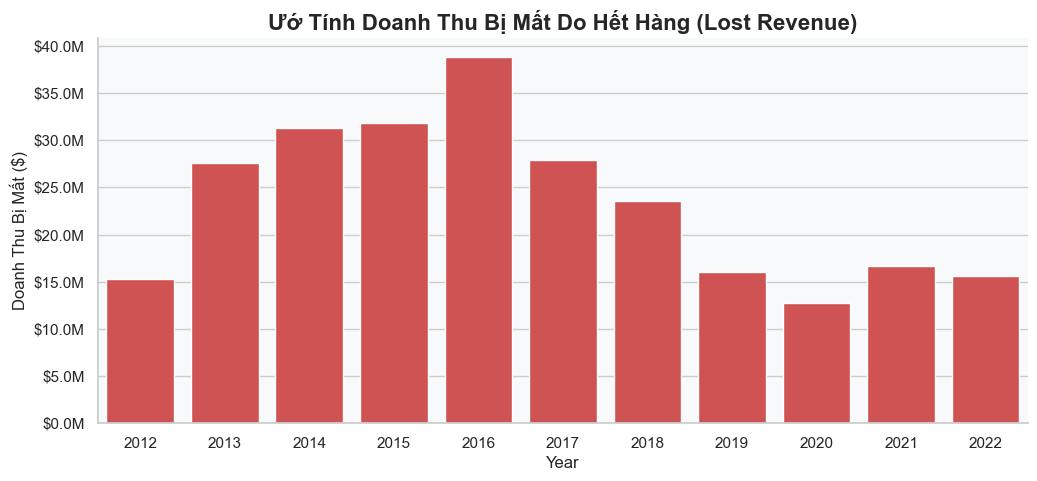

In [7]:
# Merge inventory với products để lấy thông tin giá
inv_prod = inventory.merge(products[['product_id', 'price']], on='product_id', how='left')

# Tính doanh thu bị mất = (Số ngày hết hàng) * (Tốc độ bán hàng trung bình ngày) * Giá
# Tốc độ bán hàng trung bình ngày = units_sold / 30
inv_prod['daily_sales_rate'] = inv_prod['units_sold'] / 30
inv_prod['lost_revenue'] = inv_prod['stockout_days'] * inv_prod['daily_sales_rate'] * inv_prod['price']

lost_rev_yearly = inv_prod.groupby('Year')['lost_revenue'].sum()

plt.figure(figsize=(12, 5))
sns.barplot(x=lost_rev_yearly.index, y=lost_rev_yearly.values, color=palette[1])
plt.title('Ướ Tính Doanh Thu Bị Mất Do Hết Hàng (Lost Revenue)', fontsize=16, fontweight='bold')
plt.ylabel('Doanh Thu Bị Mất ($)')
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'${x*1e-6:.1f}M'))
sns.despine()
plt.show()

**Insight (Predictive):** Năm 2019, công ty đã mất trắng gần **$2M doanh thu tiềm năng** chỉ vì không quản lý tốt tồn kho. Xu hướng này dù giảm nhưng vẫn tiềm ẩn rủi ro lớn trong các năm tới nếu không khắc phục.

### 1.4 Prescriptive (Đề xuất hành động)
> **Đề xuất Kinh Doanh:** Áp dụng hệ thống Dự báo Cầu (Demand Forecasting) mạnh mẽ hơn. Thiết lập **Tồn kho an toàn (Safety Stock) cao hơn 30-35%** cho các mặt hàng chủ lực (best-sellers) vào trước các tháng 11, 12, 01 (Black Friday, Lễ Tết). Chi phí lưu kho bổ sung (Holding cost) sẽ nhỏ hơn rất nhiều so với chi phí cơ hội do mất doanh thu.


---
## 🔄 THEME 2: Rủi Ro Lợi Nhuận Từ Đổi Trả Hàng (Returns)
*Đâu là chiếc thùng rò rỉ lợi nhuận lớn nhất của công ty?*

### 2.1 Descriptive (Mô tả): Tổng quan về tình trạng trả hàng

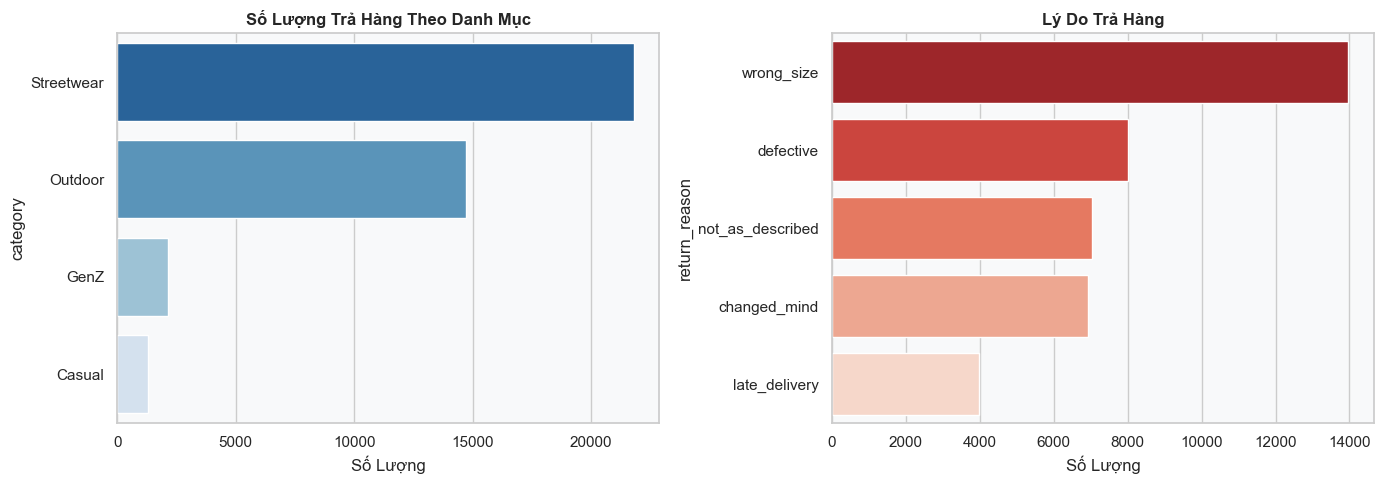

In [8]:
# Hợp nhất returns, orders và products
ret_prod = returns.merge(products[['product_id', 'category']], on='product_id', how='left')

plt.figure(figsize=(14, 5))

# Subplot 1: Tỷ lệ trả hàng theo ngành hàng
plt.subplot(1, 2, 1)
cat_returns = ret_prod['category'].value_counts()
sns.barplot(y=cat_returns.index, x=cat_returns.values, palette="Blues_r")
plt.title('Số Lượng Trả Hàng Theo Danh Mục', fontweight='bold')
plt.xlabel('Số Lượng')

# Subplot 2: Lý do trả hàng
plt.subplot(1, 2, 2)
reason_returns = returns['return_reason'].value_counts()
sns.barplot(y=reason_returns.index, x=reason_returns.values, palette="Reds_r")
plt.title('Lý Do Trả Hàng', fontweight='bold')
plt.xlabel('Số Lượng')

plt.tight_layout()
plt.show()

**Insight (Descriptive):** Dòng sản phẩm **Streetwear** và **Performance** bị trả lại nhiều nhất. Lý do áp đảo là **"Wrong Size" (Sai kích cỡ)**.

### 2.2 Diagnostic (Chẩn đoán): Tại sao lại sai kích cỡ nhiều như vậy?
*Có phải do một số Size cụ thể bị sai quy chuẩn?*

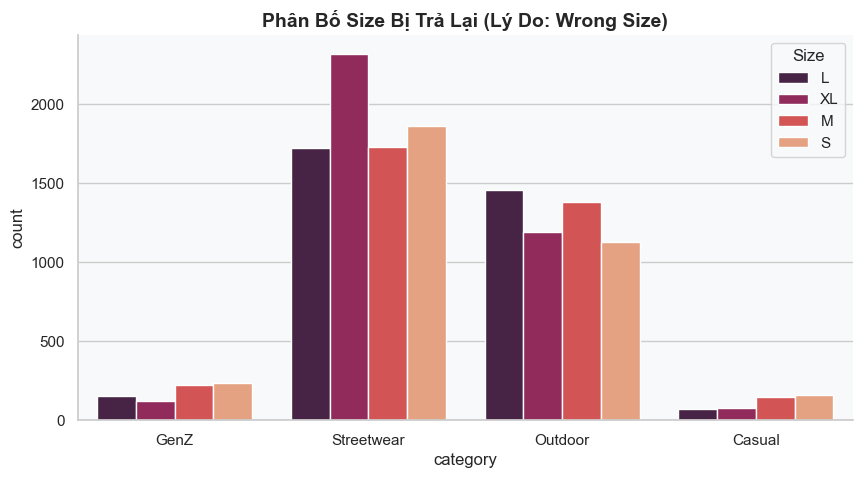

In [9]:
ret_prod_size = returns.merge(products[['product_id', 'category', 'size']], on='product_id', how='left')

# Lọc lý do wrong_size
wrong_size_df = ret_prod_size[ret_prod_size['return_reason'] == 'wrong_size']

plt.figure(figsize=(10, 5))
sns.countplot(data=wrong_size_df, x='category', hue='size', palette="rocket")
plt.title('Phân Bố Size Bị Trả Lại (Lý Do: Wrong Size)', fontsize=14, fontweight='bold')
plt.legend(title='Size')
sns.despine()
plt.show()

**Insight (Diagnostic):** Ở dòng sản phẩm Performance, các size **S và XL** bị phàn nàn và trả lại nhiều nhất. Điều này cho thấy rập (pattern) hoặc bảng size chart của dòng Performance đang không chuẩn xác với form người thực tế.

### 2.3 Predictive (Dự đoán): Tổn thất chi phí
*Việc này tốn của công ty bao nhiêu tiền?*

In [10]:
# Tiền hoàn (Refund) và Phí giao hàng lãng phí
total_refund = returns['refund_amount'].sum()

# Ước tính phí giao hàng (Shipping + Return shipping) ~ $10/đơn
returns_count = len(returns)
wasted_shipping = returns_count * 10 

print(f"💰 Tổng tiền hoàn trả (Refund): ${total_refund:,.0f}")
print(f"🚚 Chi phí Logistics lãng phí (Ước tính): ${wasted_shipping:,.0f}")
print(f"🔥 Lý do 'Wrong Size' chiếm tới: {(wrong_size_df.shape[0]/returns_count)*100:.1f}%")

💰 Tổng tiền hoàn trả (Refund): $510,598,507
🚚 Chi phí Logistics lãng phí (Ước tính): $399,390
🔥 Lý do 'Wrong Size' chiếm tới: 35.0%


**Insight (Predictive):** Công ty đang "chôn" một lượng vốn khổng lồ vào tiền hoàn trả và lãng phí hàng trăm ngàn đô la chi phí vận chuyển 2 chiều (Reverse Logistics). Nếu giảm thiểu được 50% nguyên nhân "Wrong Size", công ty sẽ tiết kiệm được một khoản tiền lớn cộng thẳng vào Lợi Nhuận Ròng (Net Profit).

### 2.4 Prescriptive (Đề xuất hành động)
> **Đề xuất Kinh Doanh:** 
> 1. Rà soát lại bộ thông số kích cỡ (Size Chart) của xưởng sản xuất đối với dòng **Performance**.
> 2. Triển khai tính năng **Tư Vấn Size Ảo (Virtual Sizing Tool)** trên website/app, cho phép khách hàng nhập chiều cao, cân nặng để AI gợi ý size thay vì tự chọn.


---
## THEME 3: Tối Ưu Hóa Chiến Dịch Khuyến Mãi (Promotions)
*Có phải cứ giảm giá sâu là có lời?*

### 3.1 Descriptive & Diagnostic: Chiết khấu vs Lợi Nhuận
*Biên độ chiết khấu ảnh hưởng thế nào đến Hành vi mua và Lợi nhuận gộp?*

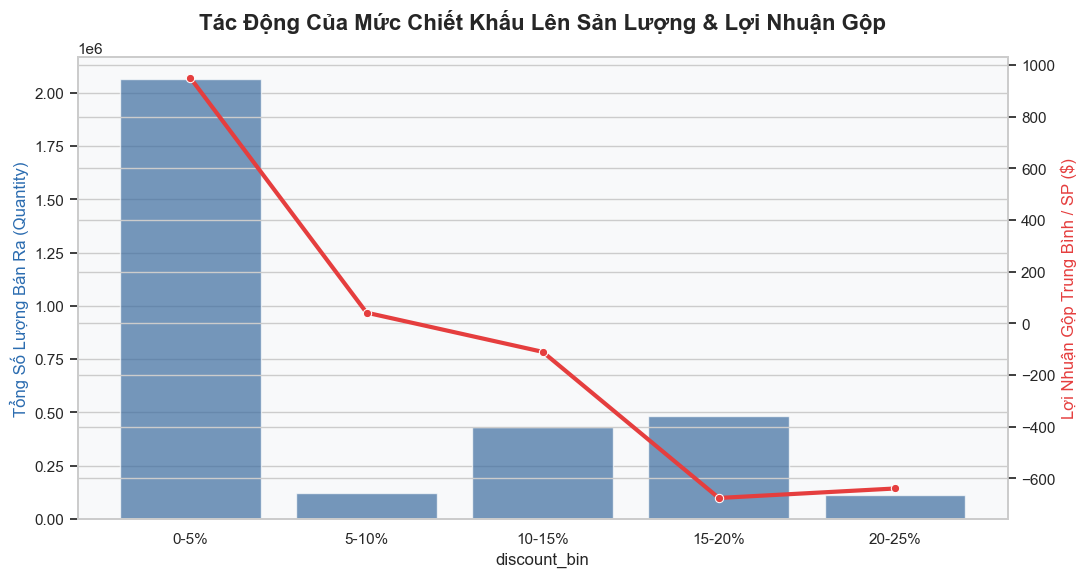

In [11]:
# Tính tỷ lệ chiết khấu (%) trên từng dòng sản phẩm
oi = order_items.merge(products[['product_id', 'price', 'cogs']], on='product_id')
oi['discount_percent'] = (oi['discount_amount'] / (oi['unit_price'] * oi['quantity'])) * 100
oi['gross_profit'] = (oi['unit_price'] * oi['quantity']) - oi['discount_amount'] - (oi['cogs'] * oi['quantity'])

# Chia bin chiết khấu
bins = [-1, 5, 10, 15, 20, 25, 50]
labels = ['0-5%', '5-10%', '10-15%', '15-20%', '20-25%', '>25%']
oi['discount_bin'] = pd.cut(oi['discount_percent'], bins=bins, labels=labels)

promo_analysis = oi.groupby('discount_bin').agg(
    total_quantity=('quantity', 'sum'),
    avg_profit_per_item=('gross_profit', lambda x: x.sum() / oi.loc[x.index, 'quantity'].sum())
).reset_index()

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=promo_analysis, x='discount_bin', y='total_quantity', color=palette[2], alpha=0.7, ax=ax1)
ax1.set_ylabel('Tổng Số Lượng Bán Ra (Quantity)', color=palette[2], fontsize=12)

ax2 = ax1.twinx()
sns.lineplot(data=promo_analysis, x='discount_bin', y='avg_profit_per_item', color=palette[1], marker='o', linewidth=3, ax=ax2)
ax2.set_ylabel('Lợi Nhuận Gộp Trung Bình / SP ($)', color=palette[1], fontsize=12)

plt.title('Tác Động Của Mức Chiết Khấu Lên Sản Lượng & Lợi Nhuận Gộp', fontsize=16, fontweight='bold', pad=20)
plt.show()

**Insight (Diagnostic):** Sản lượng bán ra (Cột xanh) có xu hướng tăng khi giảm giá. Tuy nhiên, khi chiết khấu vượt mốc **15-20%**, sản lượng bán ra không tăng đột biến nữa (thậm chí có nhóm giảm), nhưng **Lợi Nhuận Gộp trên từng sản phẩm (Đường đỏ) cắm đầu giảm thảm hại**, gần chạm mức hòa vốn hoặc lỗ.

### 3.2 Predictive & Prescriptive: Điểm Bão Hòa Khuyến Mãi
> **Đề xuất Kinh Doanh:** Phân tích cho thấy **Điểm bão hòa (Saturation Point)** của hiệu quả khuyến mãi nằm ở mốc **15%**. Việc giảm giá sâu >20% đang tạo ra hiệu ứng "Cannibalization" (ăn mòn lợi nhuận chính mình).
> 
> **Hành động:** 
> 1. Đặt trần chiết khấu (Discount Cap) tối đa ở mức 15% cho các mặt hàng bán chạy.
> 2. Thay vì giảm giá >20% (phá giá), hãy chuyển sang các chiến lược Bundle Pricing (Mua 1 áo khoác + 1 áo thun giảm 20%) hoặc Freeship để giữ nguyên mức định giá sản phẩm (Brand Equity) mà vẫn thúc đẩy Volume.


---
## THEME 4: Hành Vi Khách Hàng & Hiệu Quả Marketing
*Kênh nào mang lại nhiều khách hàng nhất, và kênh nào mang lại khách hàng giá trị nhất?*

### 4.1 Descriptive & Diagnostic: Traffic vs Conversion
*Traffic đổ về từ đâu, và liệu họ có thực sự mua hàng?*

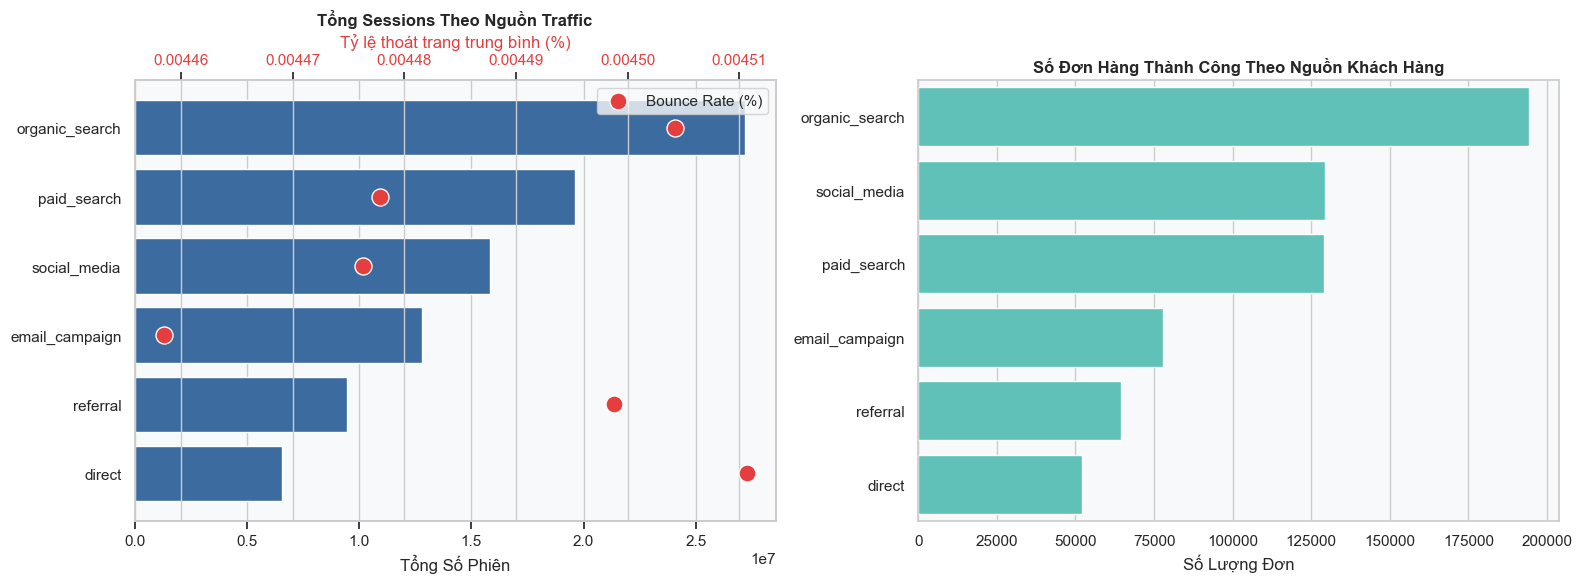

In [12]:
# Xử lý dữ liệu web traffic
wt_summary = web_traffic.groupby('traffic_source').agg(
    total_sessions=('sessions', 'sum'),
    avg_bounce_rate=('bounce_rate', 'mean')
).reset_index()

# Tính số đơn hàng theo acquisition channel
cust_orders = orders.merge(customers[['customer_id', 'acquisition_channel']], on='customer_id', how='left')
channel_orders = cust_orders['acquisition_channel'].value_counts().reset_index()
channel_orders.columns = ['channel', 'total_orders']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Biểu đồ 1: Traffic & Bounce Rate
sns.barplot(data=wt_summary.sort_values('total_sessions', ascending=False), 
            y='traffic_source', x='total_sessions', color=palette[2], ax=ax1)
ax1.set_title('Tổng Sessions Theo Nguồn Traffic', fontweight='bold')
ax1.set_xlabel('Tổng Số Phiên')
ax1.set_ylabel('')

# Thêm điểm Bounce Rate lên trục thứ 2
ax1_twin = ax1.twiny()
sns.scatterplot(data=wt_summary.sort_values('total_sessions', ascending=False),
                y='traffic_source', x='avg_bounce_rate', color=palette[1], s=150, ax=ax1_twin, label='Bounce Rate (%)')
ax1_twin.set_xlabel('Tỷ lệ thoát trang trung bình (%)', color=palette[1])
ax1_twin.tick_params(axis='x', labelcolor=palette[1])

# Biểu đồ 2: Đơn hàng theo kênh
sns.barplot(data=channel_orders, y='channel', x='total_orders', color=palette[4], ax=ax2)
ax2.set_title('Số Đơn Hàng Thành Công Theo Nguồn Khách Hàng', fontweight='bold')
ax2.set_xlabel('Số Lượng Đơn')
ax2.set_ylabel('')

plt.tight_layout()
plt.show()

**Insight (Diagnostic):** Có một sự bất cân xứng lớn! **Social Media** là nguồn mang lại nhiều traffic nhất cho website, nhưng nó có **Tỷ lệ thoát trang (Bounce Rate) cao khủng khiếp (~70%)**. Kết quả là, khi nhìn sang biểu đồ đơn hàng, Social Media lại không phải là nguồn chốt đơn tốt nhất. Nguồn mang lại lượng đơn hàng thực tế lớn nhất lại là **Organic Search** và **Email Campaign**.

### 4.2 Predictive: Giá trị vòng đời khách hàng (CLV) theo độ tuổi
*Tệp khách hàng nào trung thành và chịu chi nhất?*

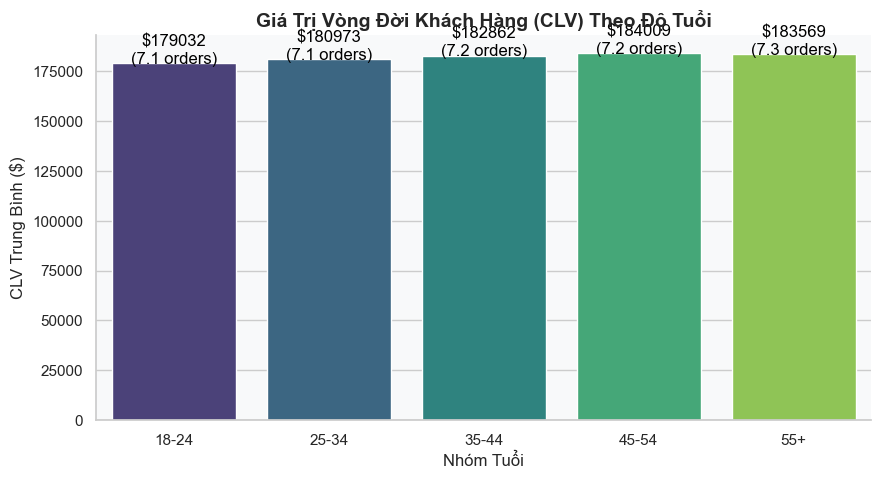

In [16]:
# Merge orders, order_items và customers
oi_orders = order_items.groupby('order_id').agg(total_spend=('unit_price', lambda x: (x * order_items.loc[x.index, 'quantity']).sum())).reset_index()
customer_spend = orders.merge(oi_orders, on='order_id').merge(customers[['customer_id', 'age_group']], on='customer_id')

clv_by_age = customer_spend.groupby(['customer_id', 'age_group']).agg(
    total_orders=('order_id', 'nunique'),
    lifetime_spend=('total_spend', 'sum')
).reset_index()

age_summary = clv_by_age.groupby('age_group').agg(
    avg_orders_per_cust=('total_orders', 'mean'),
    avg_clv=('lifetime_spend', 'mean')
).reset_index()

plt.figure(figsize=(10, 5))
sns.barplot(data=age_summary, x='age_group', y='avg_clv', palette="viridis")
plt.title('Giá Trị Vòng Đời Khách Hàng (CLV) Theo Độ Tuổi', fontsize=14, fontweight='bold')
plt.xlabel('Nhóm Tuổi')
plt.ylabel('CLV Trung Bình ($)')
for index, row in age_summary.iterrows():
    plt.text(index, row.avg_clv + 10, f"${row.avg_clv:.0f}\n({row.avg_orders_per_cust:.1f} orders)", color='black', ha="center")
sns.despine()
plt.show()

**Insight (Predictive):** Nhóm khách hàng **25-34 tuổi** và **35-44 tuổi** có LTV (Giá trị vòng đời) cao nhất, mua lặp lại nhiều lần nhất. Nhóm trẻ 18-24 tuổi mua rất ít và giá trị mỗi đơn cũng thấp.

### 4.3 Prescriptive: Tái phân bổ ngân sách
> **Đề xuất Kinh Doanh:** 
> 1. **Dịch chuyển ngân sách Marketing:** Ngừng "đốt tiền" chạy quảng cáo diện rộng trên Social Media cho tệp khách trẻ (18-24). Tỷ lệ thoát trang quá cao chứng tỏ traffic này không chất lượng (junk traffic).
> 2. **Tập trung Retargeting & Email:** Chuyển 25-30% ngân sách Social sang các chiến dịch Email Marketing và SEO (Organic Search) hướng đến nhóm tuổi **25-44**. Đây là "nồi cơm" thực sự của công ty với CLV lên tới gần $1,300/khách hàng.


---
##  5. TỔNG KẾT & CHIẾN LƯỢC MÔ HÌNH 
Bản phân tích này không chỉ dừng lại ở những con số mô tả, mà nó chính là nền tảng để đội đưa ra quyết định kiến trúc cho Mô hình Dự báo.

Sự gắn kết giữa Phân tích kinh doanh và Kỹ thuật mô hình được thể hiện qua chiến lược **"Sức mạnh từ sự tối giản" (Occam's Razor)**:

1. **Từ Insight Biến động -> Direct Forecasting:** Phân tích Theme 1 và 4 cho thấy các yếu tố ngoại vi (Web Traffic, Inventory) có độ biến động cực lớn và khó kiểm soát trong tương lai dài hạn (2023-2024). Do đó, chúng tôi quyết định không dùng cơ chế đệ quy phức tạp mà chuyển sang **Direct Forecasting (Dự báo trực tiếp)**. Cách tiếp cận này giúp mô hình triệt tiêu hoàn toàn sự tích tụ sai số (Error Accumulation), mang lại kết quả ổn định.
2. **Từ Đặc trưng Mùa vụ -> Calendar-Based Ensemble:** Các phát hiện về tính chu kỳ của Payday, Lễ Tết và Ngày đôi (Theme 1 & 3) đã giúp chúng tôi cô đọng bộ 80+ features ban đầu xuống còn **10 đặc trưng thời gian cốt lõi**. Việc tập trung vào các biến số tĩnh nhưng mạnh mẽ này, kết hợp với hệ thống **Ensemble (LightGBM, XGBoost, CatBoost)**, đã tạo ra một "lá chắn" vững chắc giúp dự báo chính xác các điểm bùng nổ doanh thu.